# Portfolio Backtester

A single-file backtesting engine that runs in Google Colab with no setup.

## How to run
1. Click **Runtime -> Run all** (or press play on the code cell).
2. **The first run installs dependencies and restarts the runtime once** - this is normal. When it reconnects, click **Runtime -> Run all again**. The second run skips the install and produces the full report.
3. To test your own portfolio, edit the `CUSTOM PORTFOLIO INPUTS` block (5-20 tickers) and run again. A **Configuration check** at the top flags anything off - e.g. custom weights that don't add up to 100% - in plain English.

Outputs: performance and risk metrics, benchmark comparison, a per-stock leaderboard, a 10,000-path Monte Carlo forecast, sector analysis, 14 charts, and a written report with a final grade.

*The one-time restart is required because installing a fresh NumPy only takes effect after the Python runtime reloads.*


Portfolio backtester

0. Configuration check
----------------------
  looks good -- no issues found.
  running: 9 tickers, custom weighting, quarterly rebalancing, 2019-01-01 to 2024-12-31

1. Downloading price data
-------------------------
  universe: ['AMD', 'AVGO', 'GOOGL', 'JPM', 'META', 'MRVL', 'NVDA', 'TSLA', 'V']
  period:   2019-01-02 to 2024-12-30 (1509 trading days)
  fetching market caps and sectors...

2. Building weights and simulating
----------------------------------
|       |   Weight % |
|-------|------------|
| AMD   |         30 |
| NVDA  |         15 |
| GOOGL |         10 |
| META  |         10 |
| JPM   |         10 |
| MRVL  |         10 |
| AVGO  |          5 |
| TSLA  |          5 |
| V     |          5 |

3. Performance metrics
----------------------
|                         |   Portfolio |     SPY |
|-------------------------|-------------|---------|
| Absolute Return %       |     868.629 | 158.402 |
| Annualized Return %     |      44.460 |  17.847 |
| C

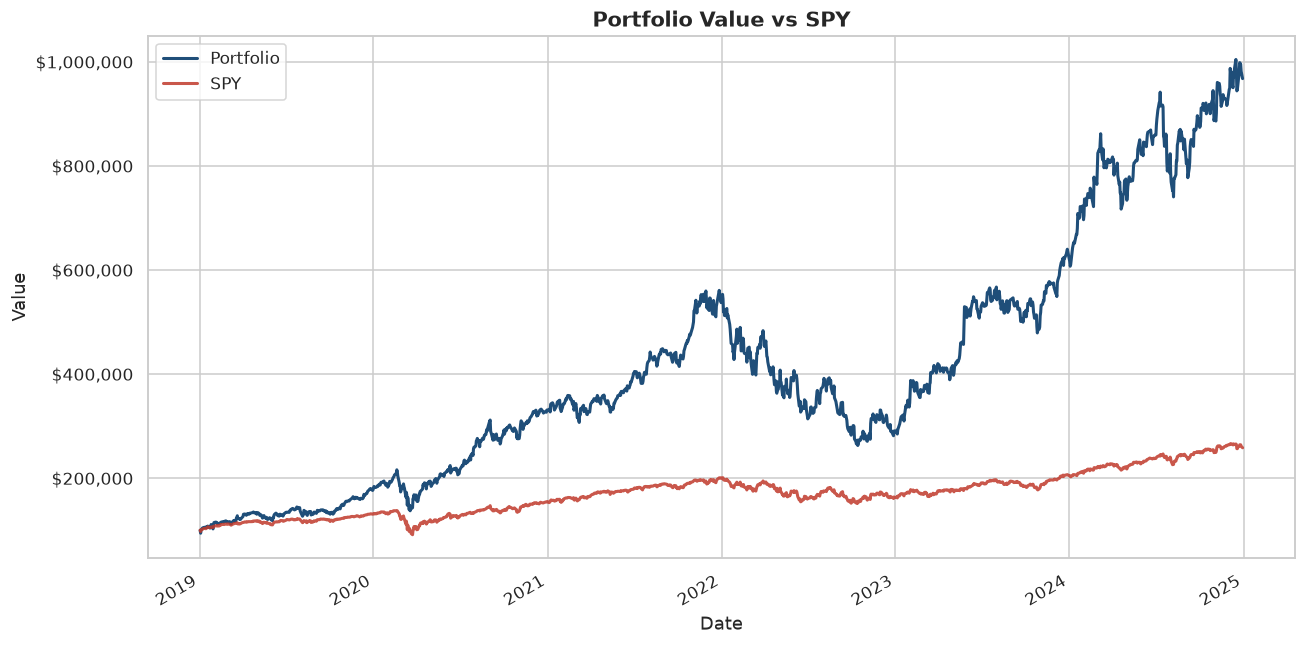

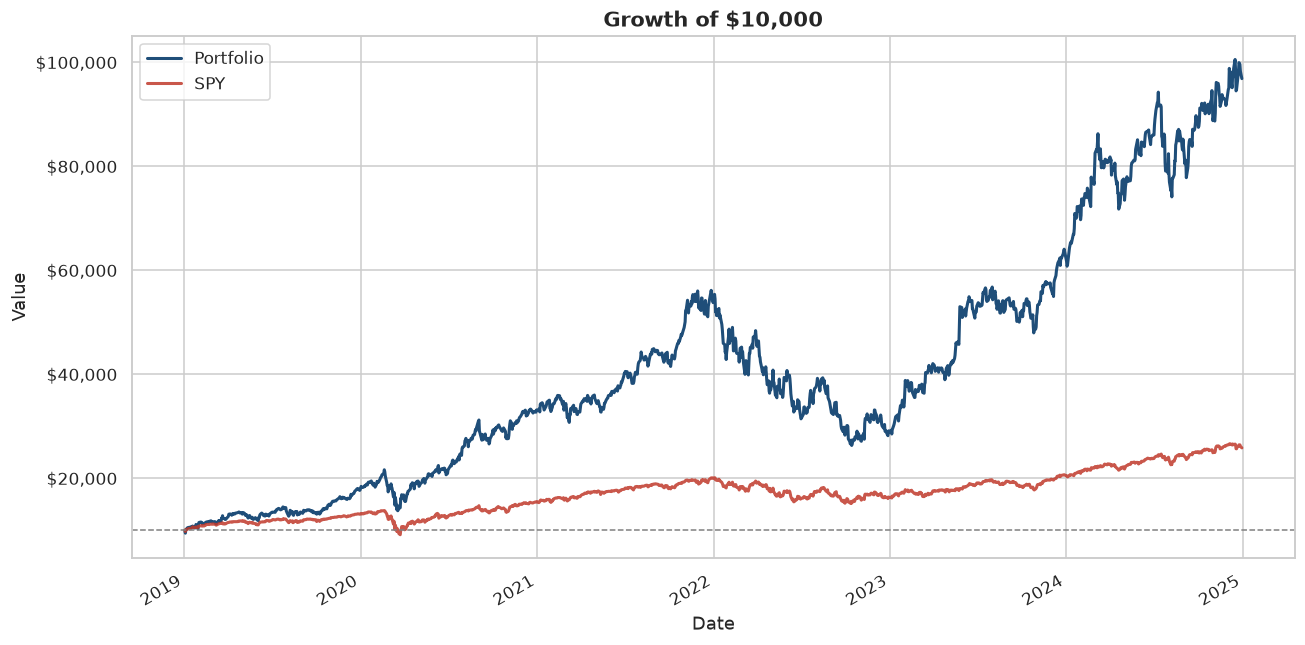

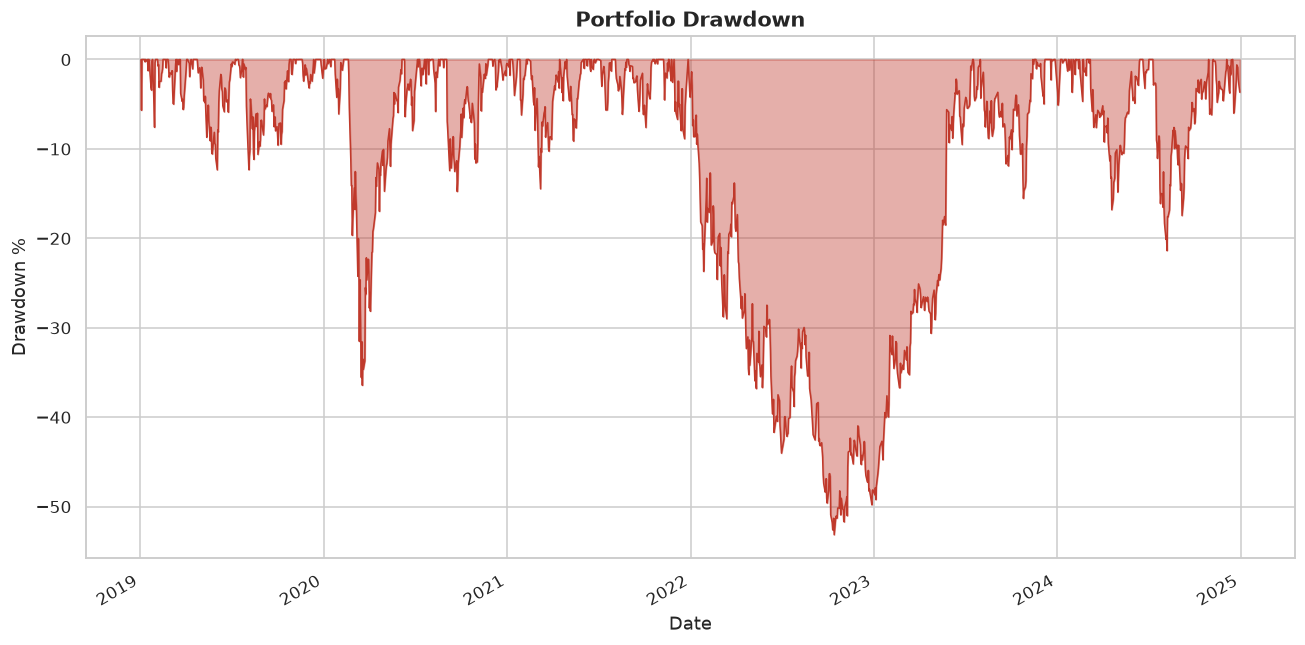

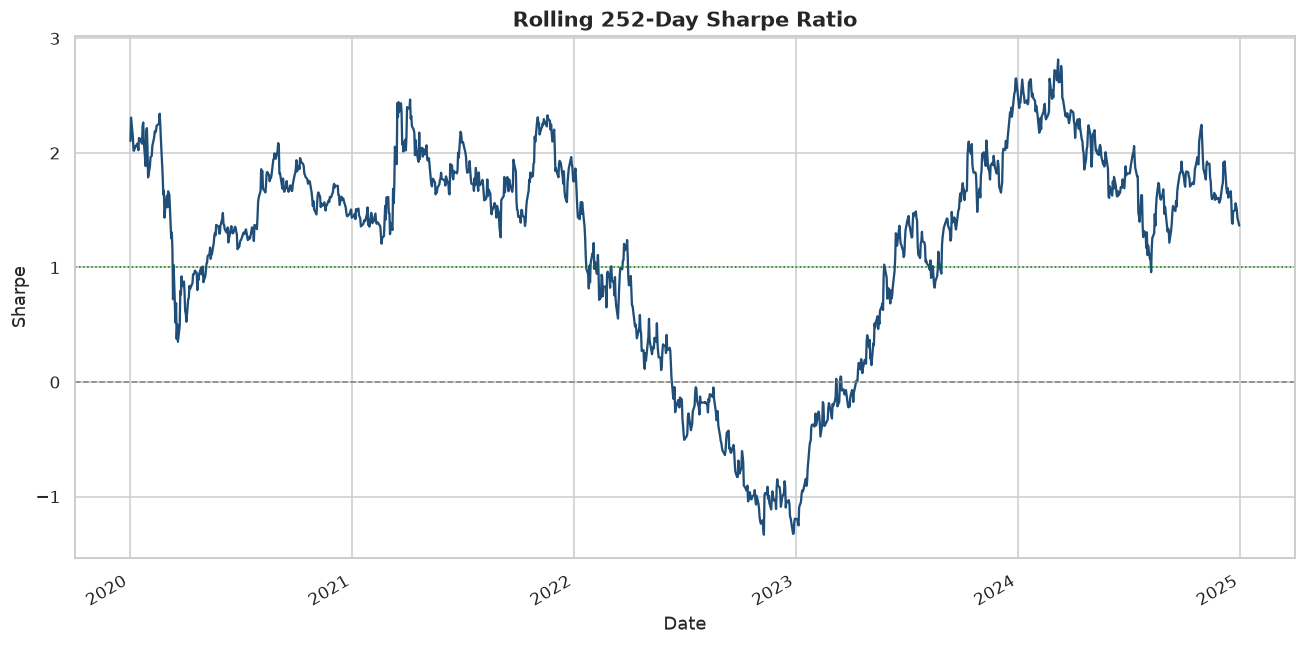

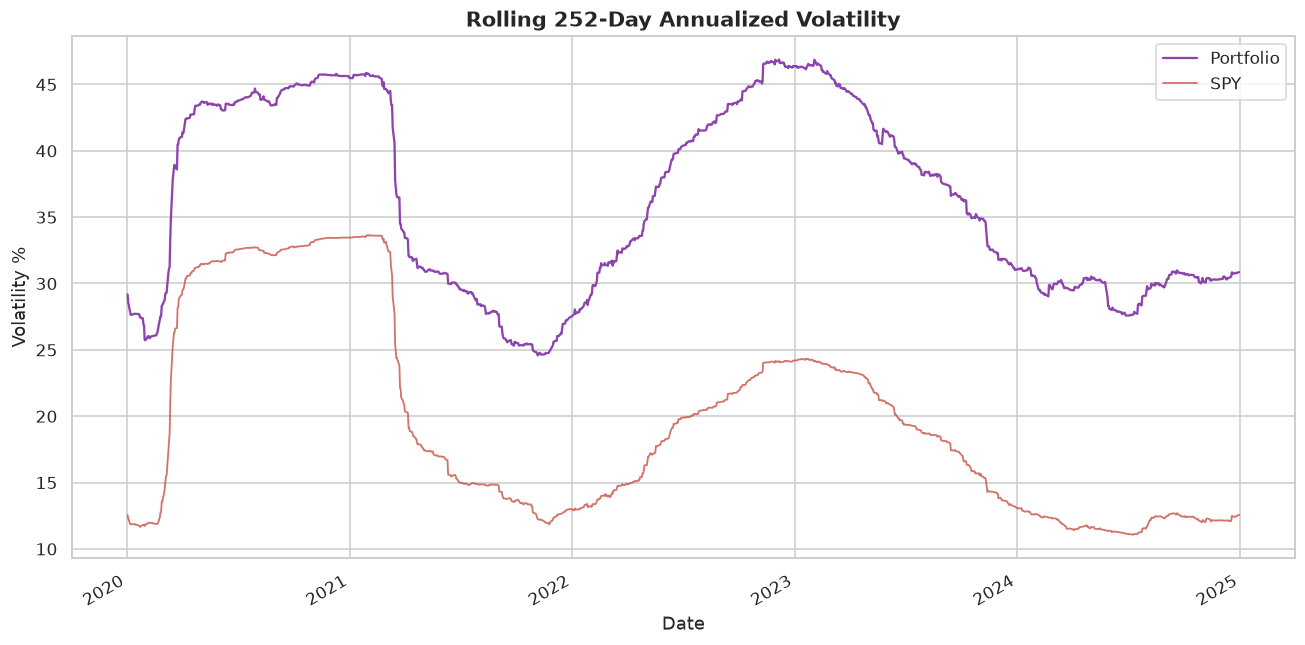

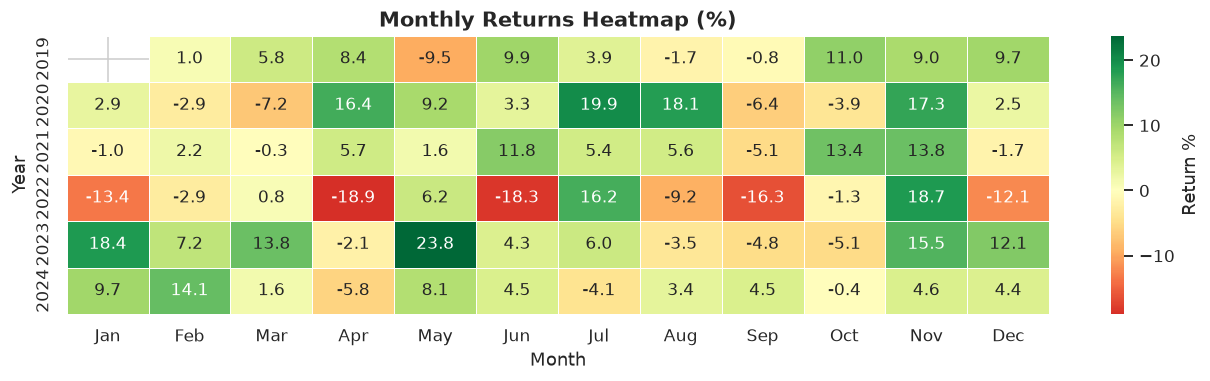

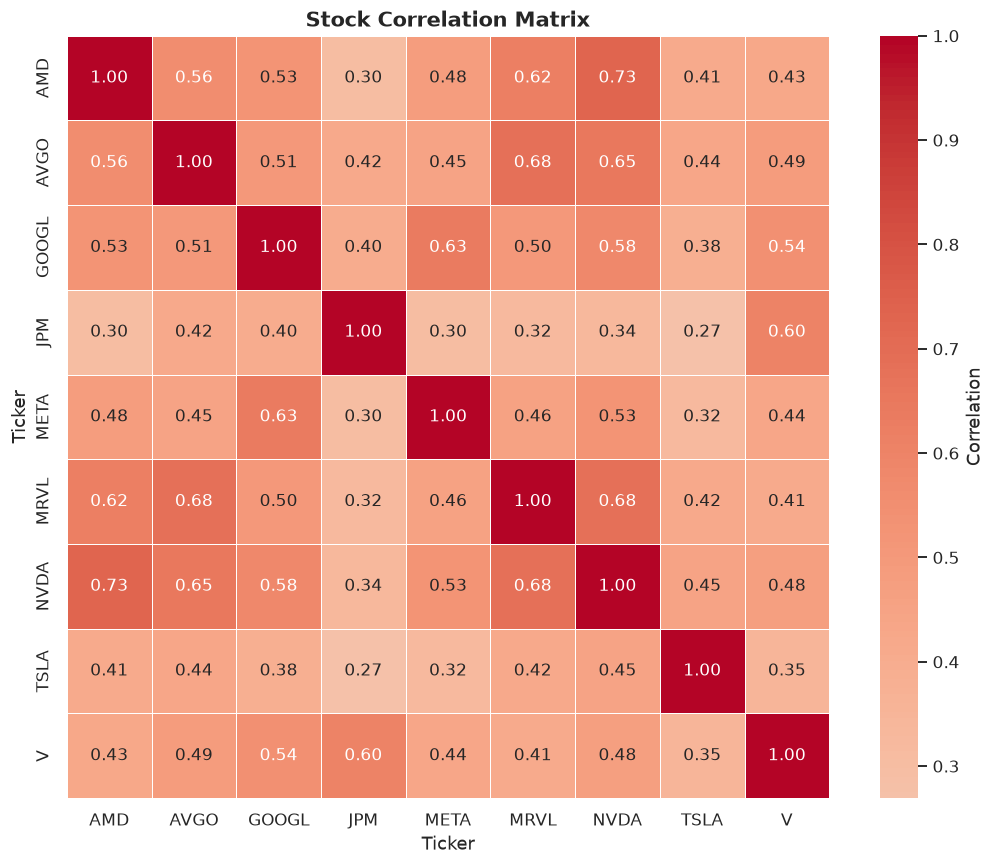

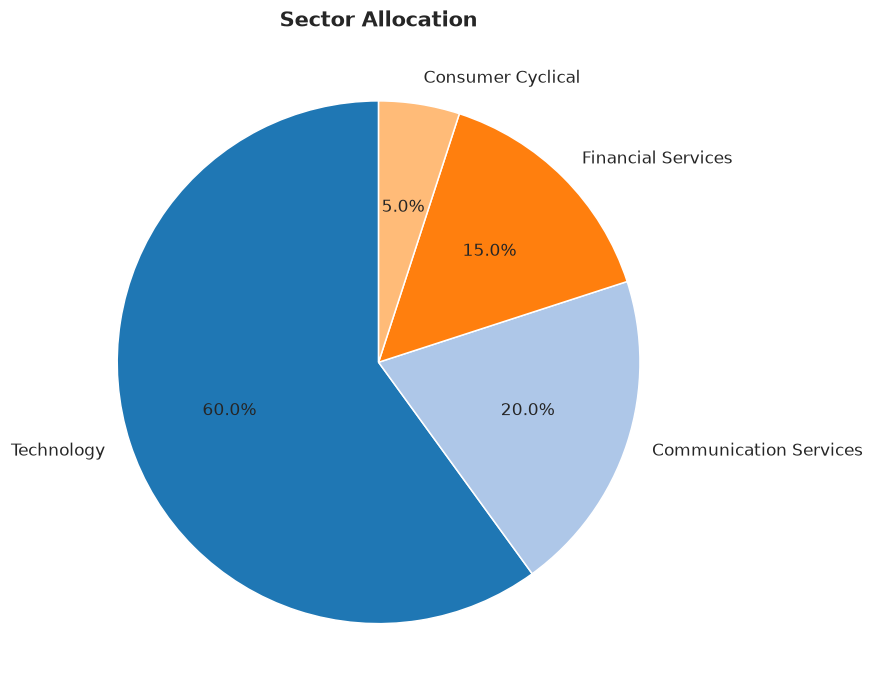

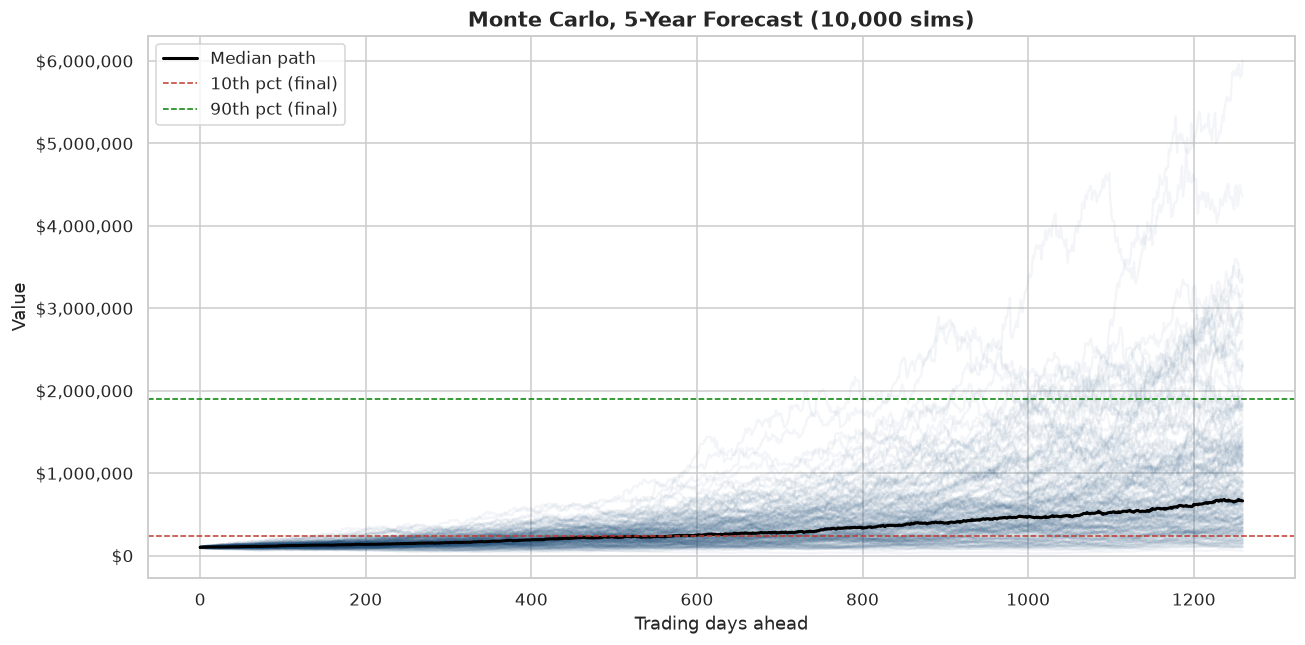

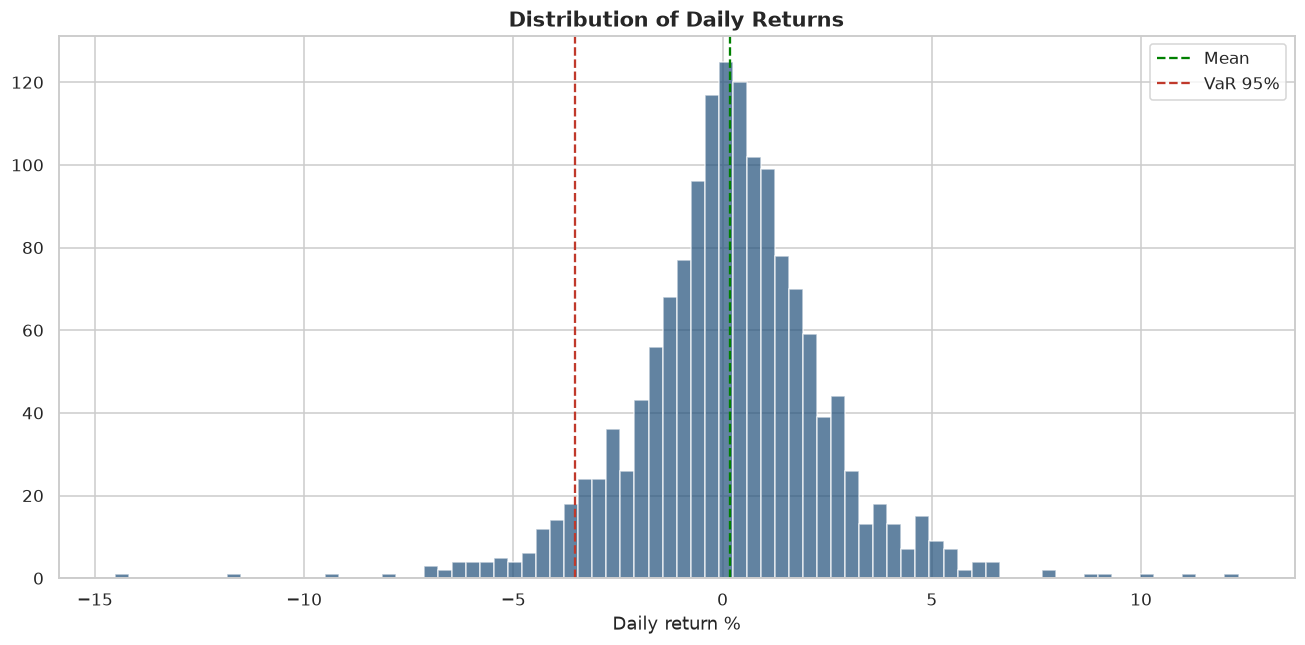

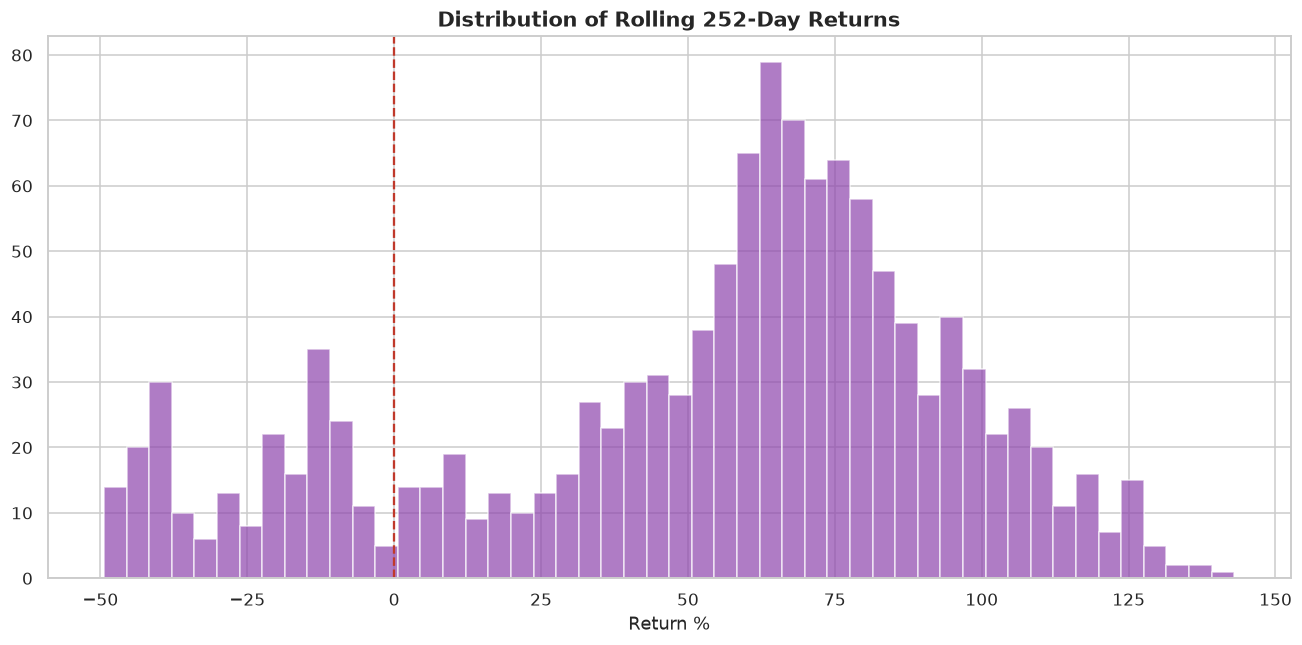

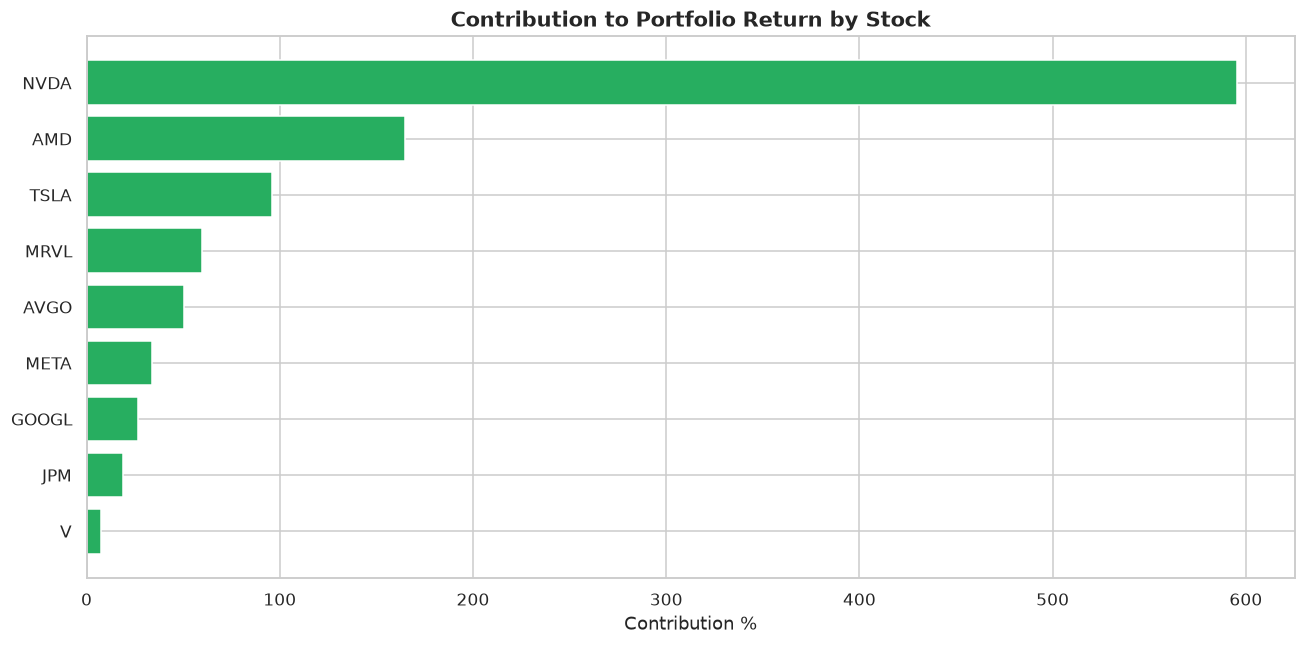

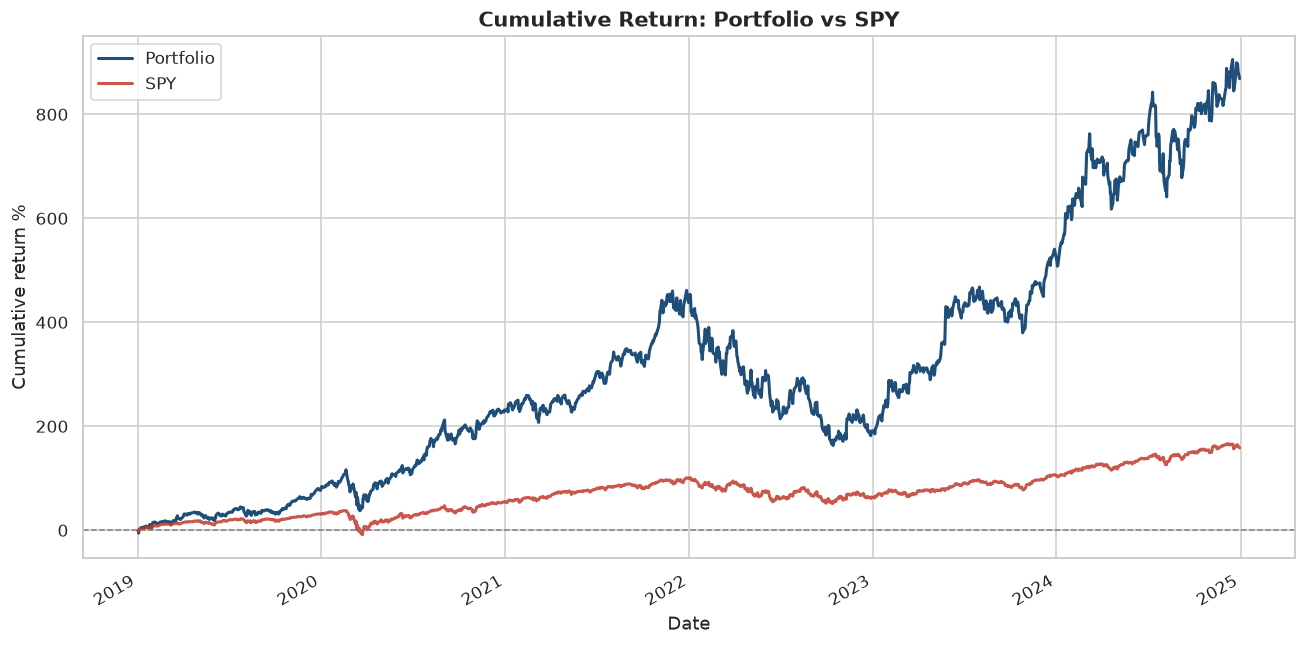

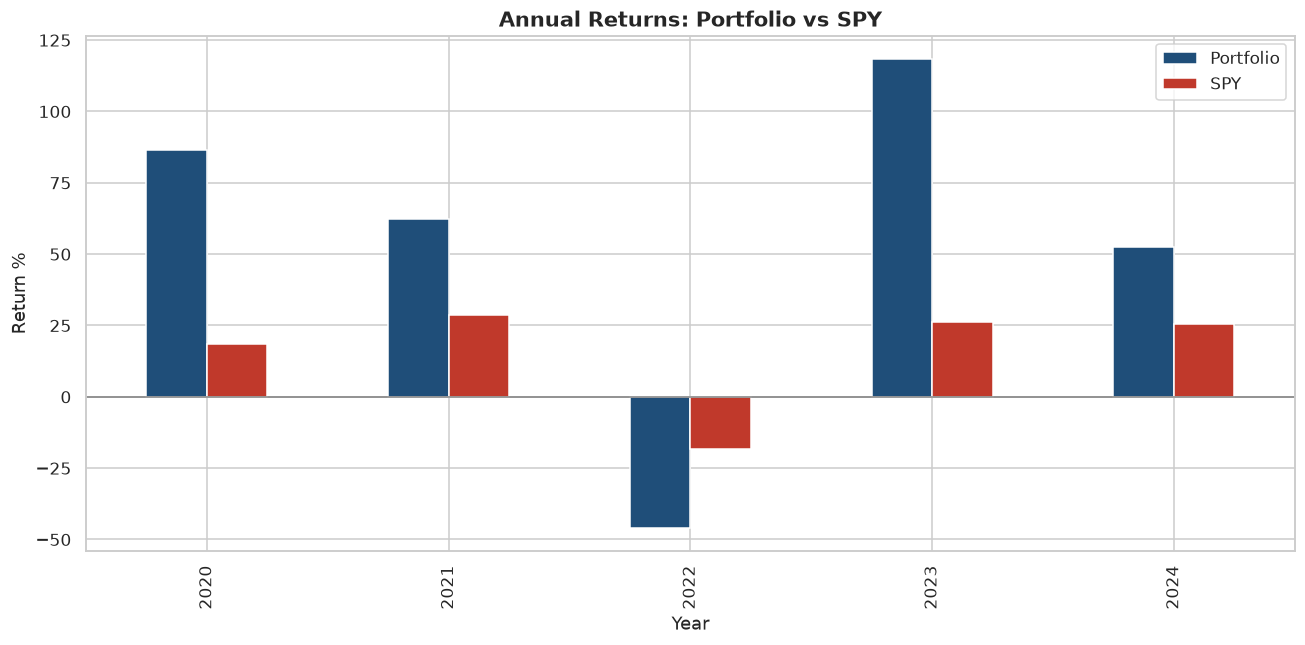

In [2]:
# Portfolio backtester
#
# A self-contained backtesting engine that runs top-to-bottom in Google Colab.
# Edit the CUSTOM PORTFOLIO INPUTS section, run everything, and you get the full
# report: performance, risk, benchmark comparison, Monte Carlo, sectors, charts.

import sys, os

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    _SETUP_DONE = "/content/_bt_setup_done"
    if not os.path.exists(_SETUP_DONE):
        print("Installing dependencies (one-time, ~30-60s)...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "--upgrade",
             "numpy", "scipy", "pandas", "matplotlib", "seaborn",
             "statsmodels", "tabulate", "yfinance"],
            check=False,
        )
        open(_SETUP_DONE, "w").close()
        print("Dependencies ready. Restarting the runtime so the new NumPy loads cleanly.")
        print(">>> When it reconnects, run the cell again (or Runtime > Run all). <<<")
        os.kill(os.getpid(), 9)   # hard restart; Colab auto-reconnects, /content persists


# %% Imports and global setup
import warnings
warnings.filterwarnings("ignore")  # silence library deprecation chatter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import yfinance as yf

from scipy import stats
import statsmodels.api as sm
from tabulate import tabulate

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "font.size": 11,
})

TRADING_DAYS = 252
MIN_STOCKS, MAX_STOCKS = 5, 20     # supported portfolio size (checked at run time)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# pandas 2.2 renamed the resample aliases (M->ME, Q->QE, A->YE). Colab ships a recent
# pandas, but we pick the right code by version so this runs on older installs too.
_PANDAS_GE_22 = tuple(int(p) for p in pd.__version__.split(".")[:2]) >= (2, 2)
RS_M = "ME" if _PANDAS_GE_22 else "M"
RS_Q = "QE" if _PANDAS_GE_22 else "Q"
RS_Y = "YE" if _PANDAS_GE_22 else "A"
P_M, P_Q = "M", "Q"                          # period codes for .to_period()
P_Y = "Y" if _PANDAS_GE_22 else "A"


def section(title):
    """Print a simple labeled header for a block of output."""
    print(f"\n{title}\n{'-' * len(title)}")


# %% CUSTOM PORTFOLIO INPUTS  -- this is the only section you need to edit

# Portfolio: 5 to 20 tickers (the engine checks this range and tells you if you're off).
TICKERS = ["AMD", "NVDA", "MRVL", "GOOGL",
           "META", "AVGO", "TSLA", "JPM", "V"]

BENCHMARK = "SPY"

START_DATE = "2019-01-01"
END_DATE   = "2024-12-31"

INITIAL_INVESTMENT = 100_000.0

# "equal", "market_cap", or "custom"
WEIGHTING_METHOD = "custom"

# Only used when WEIGHTING_METHOD == "custom". Give one weight per ticker above.
# Tips (the engine checks all of this and prints clear warnings):
#   - They are normalized to total 100%, so 0.15 / 0.30 etc. are treated as proportions.
#     Easiest is to make them add up to 1.0 (or 100) so the numbers match what you see.
#   - Every ticker in TICKERS should have a weight here; any you leave out gets 0%.
#   - Keys here that aren't in TICKERS are ignored.
CUSTOM_WEIGHTS = {
    "AMD": 0.30, "NVDA": 0.15, "MRVL": 0.10, "GOOGL": 0.10,
    "META": 0.10, "AVGO": 0.05, "TSLA": 0.05, "JPM": 0.10, "V": 0.05,
}

# "none", "monthly", "quarterly", or "yearly"
REBALANCE_FREQUENCY = "quarterly"

RISK_FREE_RATE = 0.04          # annual, e.g. 0.04 = 4%
TRANSACTION_COST = 0.0010      # fraction of traded notional, 0.0010 = 10 bps

MC_SIMULATIONS = 10_000        # Monte Carlo paths
MC_HORIZONS_YEARS = [1, 3, 5]

ROLLING_WINDOW = TRADING_DAYS  # 1-year window for rolling stats


# Bundle the inputs so the functions below stay independent of the globals.
CONFIG = dict(
    tickers=[t.upper().strip() for t in TICKERS],
    benchmark=BENCHMARK.upper().strip(),
    start=START_DATE,
    end=END_DATE,
    initial=float(INITIAL_INVESTMENT),
    weighting=WEIGHTING_METHOD.lower().strip(),
    custom_weights={k.upper(): float(v) for k, v in CUSTOM_WEIGHTS.items()},
    rebalance=REBALANCE_FREQUENCY.lower().strip(),
    rf=float(RISK_FREE_RATE),
    cost=float(TRANSACTION_COST),
    mc_sims=int(MC_SIMULATIONS),
    mc_horizons=list(MC_HORIZONS_YEARS),
    roll=int(ROLLING_WINDOW),
)


# %% Validate inputs -- catches common mistakes and explains them in plain English

def validate_config(cfg):
    """Check and clean the user inputs, printing clear warnings for anything off.

    Returns a corrected copy of cfg. Only raises (with a friendly message) for problems
    that make a backtest impossible -- everything else is fixed with a heads-up so a run
    never dies on a typo.
    """
    cfg = dict(cfg)
    notes = []   # collected warnings, shown together at the end

    # Tickers: clean, de-duplicate, and drop the benchmark if it slipped into the list.
    seen, tickers = set(), []
    for t in cfg["tickers"]:
        t = str(t).upper().strip()
        if t and t not in seen:
            seen.add(t)
            tickers.append(t)
    if cfg["benchmark"] in tickers:
        tickers.remove(cfg["benchmark"])
        notes.append(f"Removed {cfg['benchmark']} from the portfolio -- it's the benchmark "
                     f"you're comparing against, not a holding.")

    # Portfolio size: aim for MIN_STOCKS..MAX_STOCKS.
    if len(tickers) > MAX_STOCKS:
        notes.append(f"You listed {len(tickers)} tickers; using the first {MAX_STOCKS} "
                     f"(the supported maximum).")
        tickers = tickers[:MAX_STOCKS]
    if len(tickers) < 2:
        raise ValueError(f"Need at least 2 valid tickers to run a portfolio "
                         f"(you have {len(tickers)}). Add more to TICKERS.")
    if len(tickers) < MIN_STOCKS:
        notes.append(f"Only {len(tickers)} tickers -- below the recommended {MIN_STOCKS}. "
                     f"It will still run, but diversification stats will be thin.")
    cfg["tickers"] = tickers

    # Weighting method.
    if cfg["weighting"] not in ("equal", "market_cap", "custom"):
        notes.append(f"Unknown weighting '{cfg['weighting']}' -- using equal weight.")
        cfg["weighting"] = "equal"

    # Custom weights: the part people trip on. Reconcile against the ticker list and
    # explain the normalization instead of silently rescaling.
    if cfg["weighting"] == "custom":
        cw = {k.upper().strip(): float(v) for k, v in cfg["custom_weights"].items()}
        neg = [k for k, v in cw.items() if v < 0]
        if neg:
            notes.append(f"Negative custom weight(s) set to 0: {', '.join(neg)}.")
            cw = {k: max(v, 0.0) for k, v in cw.items()}
        missing = [t for t in tickers if t not in cw]
        extra = [k for k in cw if k not in tickers]
        if missing:
            notes.append(f"No custom weight for {', '.join(missing)} -- they'll get 0%. "
                         f"Add them to CUSTOM_WEIGHTS if that isn't intended.")
        if extra:
            notes.append(f"Ignoring custom weight(s) for tickers not in your list: "
                         f"{', '.join(extra)}.")
        used = {t: cw.get(t, 0.0) for t in tickers}
        raw_sum = sum(used.values())
        if raw_sum <= 0:
            notes.append("All custom weights are 0 -- using equal weight instead.")
            cfg["weighting"] = "equal"
        elif abs(raw_sum - 1.0) > 0.01:
            notes.append(
                f"Custom weights total {raw_sum * 100:.1f}%, not 100%, so they'll be "
                f"scaled to 100% (each divided by {raw_sum:.3f}). That's why a typed 15% "
                f"can show up smaller. To make displayed weights match what you type, edit "
                f"them to add up to 1.0.")
        cfg["custom_weights"] = used

    # Rebalancing.
    if cfg["rebalance"] not in ("none", "monthly", "quarterly", "yearly"):
        notes.append(f"Unknown rebalance '{cfg['rebalance']}' -- using 'none'.")
        cfg["rebalance"] = "none"

    # Dates.
    try:
        start, end = pd.to_datetime(cfg["start"]), pd.to_datetime(cfg["end"])
    except Exception:
        raise ValueError("START_DATE / END_DATE must be dates like '2019-01-01'.")
    if start >= end:
        raise ValueError(f"START_DATE ({cfg['start']}) must be before END_DATE ({cfg['end']}).")
    if (end - start).days < 90:
        notes.append("Date range is under ~3 months; many statistics need more history "
                     "to mean much.")

    # Money, rates, costs, simulation count.
    if cfg["initial"] <= 0:
        raise ValueError("INITIAL_INVESTMENT must be a positive number.")
    if not (0 <= cfg["rf"] < 1):
        notes.append(f"RISK_FREE_RATE is {cfg['rf']} -- expected a decimal like 0.04 (=4%). "
                     f"Did you enter a percent by mistake?")
    if not (0 <= cfg["cost"] < 0.1):
        notes.append(f"TRANSACTION_COST is {cfg['cost']} -- expected a small fraction like "
                     f"0.001 (=0.1%). Double-check the value.")
    if cfg["mc_sims"] < 1000:
        notes.append(f"MC_SIMULATIONS is low ({cfg['mc_sims']}); 10,000+ is smoother.")

    section("0. Configuration check")
    for n in notes:
        print(f"  - {n}")
    if not notes:
        print("  looks good -- no issues found.")
    print(f"  running: {len(cfg['tickers'])} tickers, {cfg['weighting']} weighting, "
          f"{cfg['rebalance']} rebalancing, {cfg['start']} to {cfg['end']}")
    return cfg


# %% Data collection

def download_prices(tickers, start, end, max_missing_pct=0.10, attempts=3):
    """Download adjusted-close prices and volume, dropping anything too patchy.

    auto_adjust=True gives split/dividend-adjusted closes, which is what we want for
    total-return backtesting. Yahoo sometimes returns nothing on the first try, so we
    retry a few times and raise a clear, friendly error if no usable data comes back.
    Tickers with too many gaps (or none at all) are reported and skipped.
    """
    import time
    if isinstance(tickers, str):
        tickers = [tickers]
    requested = list(tickers)

    raw = None
    for attempt in range(1, attempts + 1):
        try:
            raw = yf.download(tickers, start=start, end=end, auto_adjust=True,
                              progress=False, group_by="column")
            if raw is not None and not raw.empty:
                break
        except Exception as e:
            print(f"  download attempt {attempt}/{attempts} failed: {e}")
        if attempt < attempts:
            time.sleep(2)

    if raw is None or raw.empty:
        raise RuntimeError(
            "Yahoo Finance returned no data. This is usually a temporary rate limit -- "
            "wait a minute and run the cell again. Also double-check your tickers and that "
            "the dates aren't in the future.")

    # yfinance returns a different shape for one vs. many tickers, so handle both.
    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" not in raw.columns.get_level_values(0):
            raise RuntimeError("Downloaded data has no 'Close' prices -- check your tickers.")
        prices = raw["Close"].copy()
        has_vol = "Volume" in raw.columns.get_level_values(0)
        volume = raw["Volume"].copy() if has_vol else pd.DataFrame()
    else:
        prices = raw[["Close"]].copy()
        prices.columns = requested[:1]
        volume = raw[["Volume"]].copy() if "Volume" in raw.columns else pd.DataFrame()
        if not volume.empty:
            volume.columns = requested[:1]

    if isinstance(prices, pd.Series):
        prices = prices.to_frame()
    prices = prices.dropna(how="all")
    if not volume.empty:
        volume = volume.reindex(columns=prices.columns)

    # Tickers that came back with no data at all -- usually a typo or a delisting.
    invalid = [t for t in requested if t not in prices.columns]
    if invalid:
        print(f"  no data for {', '.join(invalid)} (check spelling / availability) -- skipping")

    # Drop tickers with too many gaps.
    keep, dropped = [], list(invalid)
    for col in prices.columns:
        missing = prices[col].isna().mean()
        if missing > max_missing_pct:
            dropped.append(col)
            print(f"  dropping {col}: {missing:.0%} of data missing")
        else:
            keep.append(col)
    prices = prices[keep]

    if prices.shape[1] == 0:
        raise RuntimeError(
            "None of the requested tickers had usable data for this date range. Check the "
            "tickers and that the dates aren't in the future, then run again.")

    # Fill the small remaining gaps.
    prices = prices.ffill().bfill()
    if not volume.empty:
        volume = volume.reindex(columns=keep).ffill().fillna(0)
    return prices, volume, dropped


def fetch_fundamentals(tickers):
    """Return a market_cap / sector table, falling back gracefully per ticker."""
    rows = {}
    for t in tickers:
        mcap, sector = np.nan, "Unknown"
        try:
            info = yf.Ticker(t).info or {}
            mcap = info.get("marketCap", np.nan)
            sector = info.get("sector", None) or "Unknown"
        except Exception as e:
            print(f"  couldn't fetch fundamentals for {t}: {e}")
        rows[t] = {"market_cap": mcap, "sector": sector}
    return pd.DataFrame(rows).T


# %% Portfolio construction

def build_weights(tickers, method, custom_weights, market_caps):
    """Return normalized target weights (summing to 1) for the chosen method."""
    if method == "equal":
        w = pd.Series(1.0, index=tickers)

    elif method == "market_cap":
        caps = market_caps.reindex(tickers).astype(float)
        if caps.isna().all() or caps.fillna(0).sum() == 0:
            print("  market caps unavailable, using equal weight instead")
            w = pd.Series(1.0, index=tickers)
        else:
            w = caps.fillna(caps.median())   # unknown caps default to the median

    elif method == "custom":
        w = pd.Series({t: custom_weights.get(t, 0.0) for t in tickers})
        if w.sum() == 0:
            print("  custom weights are all zero, using equal weight instead")
            w = pd.Series(1.0, index=tickers)

    else:
        raise ValueError(f"unknown weighting method: {method}")

    w = w.clip(lower=0)          # long-only
    return w / w.sum()


def get_rebalance_dates(dates, frequency):
    """Trading days we rebalance on: the last available day of each period."""
    if frequency == "none":
        return set()
    rule = {"monthly": P_M, "quarterly": P_Q, "yearly": P_Y}[frequency]
    periods = dates.to_period(rule)
    last_per_period = pd.Series(dates, index=periods).groupby(level=0).last()
    return set(pd.to_datetime(last_per_period.values))


def simulate_portfolio(prices, weights, initial, rebalance, cost):
    """Track portfolio value day by day, with rebalancing and trading costs.

    Day 0 buys the target weights (and pays cost on the initial notional). Each day
    the holdings grow with their returns and the weights drift; on a rebalance date we
    trade back to target and pay cost on the turnover. Returns the value series and a
    history of end-of-day weights.
    """
    rets = prices.pct_change().fillna(0.0)
    dates = prices.index
    assets = prices.columns
    target = weights.reindex(assets).fillna(0.0)
    rebalance_dates = get_rebalance_dates(dates, rebalance)

    cash = initial * (1.0 - cost)            # initial purchase cost
    holdings = target * cash                 # dollars per asset
    values, w_hist = [], []

    for i, date in enumerate(dates):
        if i > 0:
            holdings = holdings * (1.0 + rets.iloc[i])
        total = holdings.sum()

        if i > 0 and date in rebalance_dates:
            desired = target * total
            turnover = (desired - holdings).abs().sum() / 2.0   # one-way traded notional
            total -= turnover * cost
            holdings = target * total

        values.append(total)
        w_hist.append((holdings / total).values if total > 0 else target.values)

    value = pd.Series(values, index=dates, name="Portfolio")
    weights_history = pd.DataFrame(w_hist, index=dates, columns=assets)
    return value, weights_history


def benchmark_value_series(bench_prices, initial):
    """Grow `initial` along the benchmark's price path (buy and hold)."""
    bench = bench_prices.iloc[:, 0] if isinstance(bench_prices, pd.DataFrame) else bench_prices
    return (bench / bench.iloc[0] * initial).rename("Benchmark")


# %% Performance metrics

def to_returns(value):
    """Daily simple returns from a value/price series."""
    return value.pct_change().dropna()


def cagr(value, periods_per_year=TRADING_DAYS):
    n_years = len(value) / periods_per_year
    if n_years <= 0:
        return np.nan
    return (value.iloc[-1] / value.iloc[0]) ** (1 / n_years) - 1


def annualized_return(returns, periods_per_year=TRADING_DAYS):
    """Arithmetic annualized return (mean daily return scaled up)."""
    return returns.mean() * periods_per_year


def annualized_vol(returns, periods_per_year=TRADING_DAYS):
    return returns.std() * np.sqrt(periods_per_year)


def sharpe_ratio(returns, rf=0.0, periods_per_year=TRADING_DAYS):
    excess = returns - rf / periods_per_year
    if excess.std() == 0:
        return np.nan
    return (excess.mean() / excess.std()) * np.sqrt(periods_per_year)


def sortino_ratio(returns, rf=0.0, periods_per_year=TRADING_DAYS):
    """Like Sharpe, but only penalizes downside volatility."""
    excess = returns - rf / periods_per_year
    downside = excess[excess < 0].std()
    if downside == 0 or np.isnan(downside):
        return np.nan
    return (excess.mean() / downside) * np.sqrt(periods_per_year)


def drawdown_series(value):
    """Running drawdown: value divided by its running peak, minus 1."""
    return value / value.cummax() - 1.0


def max_drawdown(value):
    return drawdown_series(value).min()


def calmar_ratio(value, periods_per_year=TRADING_DAYS):
    mdd = abs(max_drawdown(value))
    return cagr(value, periods_per_year) / mdd if mdd else np.nan


def beta_alpha(returns, bench_returns, rf=0.0, periods_per_year=TRADING_DAYS):
    """CAPM beta, annualized Jensen alpha, and R-squared from an OLS fit.

    Regresses portfolio excess return on benchmark excess return.
    """
    rf_daily = rf / periods_per_year
    df = pd.concat([returns, bench_returns], axis=1).dropna()
    df.columns = ["p", "b"]
    if len(df) < 3 or df["b"].std() == 0:   # too few points / flat benchmark -> undefined
        return np.nan, np.nan, np.nan
    y = df["p"] - rf_daily
    X = sm.add_constant(df["b"] - rf_daily)
    model = sm.OLS(y, X).fit()
    beta = model.params["b"]
    alpha_annual = (1 + model.params["const"]) ** periods_per_year - 1
    return beta, alpha_annual, model.rsquared


def treynor_ratio(returns, bench_returns, rf=0.0, periods_per_year=TRADING_DAYS):
    """Excess return per unit of market (beta) risk."""
    beta, _, _ = beta_alpha(returns, bench_returns, rf, periods_per_year)
    if not beta:
        return np.nan
    return (annualized_return(returns, periods_per_year) - rf) / beta


def tracking_error(returns, bench_returns, periods_per_year=TRADING_DAYS):
    active = (returns - bench_returns).dropna()
    return active.std() * np.sqrt(periods_per_year)


def information_ratio(returns, bench_returns, periods_per_year=TRADING_DAYS):
    """Active return divided by tracking error."""
    active = (returns - bench_returns).dropna()
    if active.std() == 0:
        return np.nan
    return (active.mean() / active.std()) * np.sqrt(periods_per_year)


def capture_ratios(returns, bench_returns):
    """Upside / downside capture, on monthly returns. >100 up and <100 down is good."""
    p_m = (1 + returns).resample(RS_M).prod() - 1
    b_m = (1 + bench_returns).resample(RS_M).prod() - 1
    df = pd.concat([p_m, b_m], axis=1).dropna()
    df.columns = ["p", "b"]

    def geo(x):
        return (np.prod(1 + x)) ** (1 / len(x)) - 1 if len(x) else np.nan

    up, down = df[df["b"] > 0], df[df["b"] < 0]
    up_cap = (geo(up["p"]) / geo(up["b"]) * 100) if len(up) and geo(up["b"]) != 0 else np.nan
    dn_cap = (geo(down["p"]) / geo(down["b"]) * 100) if len(down) and geo(down["b"]) != 0 else np.nan
    return up_cap, dn_cap


def monthly_stats(value):
    """Month-level summary stats from a daily value series."""
    m = value.resample(RS_M).last().pct_change().dropna()
    return {
        "monthly_returns": m,
        "best_month": m.max(),
        "worst_month": m.min(),
        "positive_month_pct": (m > 0).mean(),
        "avg_monthly_return": m.mean(),
        "win_rate_daily": (to_returns(value) > 0).mean(),
    }


def value_at_risk(returns, level=0.95):
    """Historical VaR: the daily loss you don't expect to exceed (positive number)."""
    return -np.percentile(returns, (1 - level) * 100)


def conditional_var(returns, level=0.95):
    """Average loss in the worst (1-level) tail of days."""
    threshold = -value_at_risk(returns, level)
    tail = returns[returns <= threshold]
    return -tail.mean() if len(tail) else np.nan


def compute_all_metrics(value, bench_value, rf, label="Portfolio"):
    """The full metric set for one value series, ready to drop into a DataFrame."""
    r = to_returns(value)
    br = to_returns(bench_value)
    beta, alpha, r2 = beta_alpha(r, br, rf)
    up_cap, dn_cap = capture_ratios(r, br)
    ms = monthly_stats(value)

    return {
        "Absolute Return %":       (value.iloc[-1] / value.iloc[0] - 1) * 100,
        "Annualized Return %":     annualized_return(r) * 100,
        "CAGR %":                  cagr(value) * 100,
        "Annualized Volatility %": annualized_vol(r) * 100,
        "Sharpe Ratio":            sharpe_ratio(r, rf),
        "Sortino Ratio":           sortino_ratio(r, rf),
        "Max Drawdown %":          max_drawdown(value) * 100,
        "Calmar Ratio":            calmar_ratio(value),
        "Beta vs SPY":             beta,
        "Alpha (annual) %":        alpha * 100,
        "Treynor Ratio":           treynor_ratio(r, br, rf),
        "Information Ratio":       information_ratio(r, br),
        "Tracking Error %":        tracking_error(r, br) * 100,
        "Upside Capture %":        up_cap,
        "Downside Capture %":      dn_cap,
        "Win Rate (daily) %":      ms["win_rate_daily"] * 100,
        "Best Month %":            ms["best_month"] * 100,
        "Worst Month %":           ms["worst_month"] * 100,
        "Positive Months %":       ms["positive_month_pct"] * 100,
        "Avg Monthly Return %":    ms["avg_monthly_return"] * 100,
        "VaR 95% (daily) %":       value_at_risk(r) * 100,
        "CVaR 95% (daily) %":      conditional_var(r) * 100,
        "R-squared vs SPY":        r2,
    }


# %% Benchmark comparison

def benchmark_comparison(port_value, bench_value, rf):
    """Side-by-side table plus a plain-English beat-the-market verdict."""
    pr, brr = to_returns(port_value), to_returns(bench_value)

    rows = {
        "Total Return %":  [(port_value.iloc[-1] / port_value.iloc[0] - 1) * 100,
                            (bench_value.iloc[-1] / bench_value.iloc[0] - 1) * 100],
        "CAGR %":          [cagr(port_value) * 100, cagr(bench_value) * 100],
        "Volatility %":    [annualized_vol(pr) * 100, annualized_vol(brr) * 100],
        "Sharpe Ratio":    [sharpe_ratio(pr, rf), sharpe_ratio(brr, rf)],
        "Max Drawdown %":  [max_drawdown(port_value) * 100, max_drawdown(bench_value) * 100],
    }
    table = pd.DataFrame(rows, index=["Portfolio", "Benchmark (SPY)"]).T
    table["Difference"] = table["Portfolio"] - table["Benchmark (SPY)"]

    beta, alpha, r2 = beta_alpha(pr, brr, rf)
    outperf = (port_value.iloc[-1] / port_value.iloc[0]) - (bench_value.iloc[-1] / bench_value.iloc[0])
    extras = {
        "Outperformance % (total)": outperf * 100,
        "Annual Alpha %":           alpha * 100,
        "Correlation to SPY":       pr.corr(brr),
        "R-squared":                r2,
    }

    beat = port_value.iloc[-1] > bench_value.iloc[-1]
    verdict = ("Yes, the portfolio beat the market."
               if beat else "No, the portfolio trailed the market.")
    return table, extras, beat, verdict


# %% Individual stock leaderboard

def stock_leaderboard(prices, weights, port_value, rf):
    """Per-stock stats ranked best to worst, with contribution to total return.

    Contribution is weight times the stock's total return, which sums close to the
    portfolio's own total return.
    """
    port_rets = to_returns(port_value)
    rows = {}
    for t in prices.columns:
        v = prices[t]
        r = to_returns(v)
        rows[t] = {
            "Weight %":            weights.get(t, 0.0) * 100,
            "Total Return %":      (v.iloc[-1] / v.iloc[0] - 1) * 100,
            "Annualized Return %": annualized_return(r) * 100,
            "Volatility %":        annualized_vol(r) * 100,
            "Sharpe":              sharpe_ratio(r, rf),
            "Max Drawdown %":      max_drawdown(v) * 100,
            "Contribution %":      weights.get(t, 0.0) * (v.iloc[-1] / v.iloc[0] - 1) * 100,
            "Corr w/ Portfolio":   r.corr(port_rets),
        }
    lb = pd.DataFrame(rows).T.sort_values("Total Return %", ascending=False)
    lb.insert(0, "Rank", range(1, len(lb) + 1))
    return lb


# %% Risk analysis

def largest_drawdowns(value, top_n=5):
    """The deepest distinct drawdown episodes, with their start/trough/end dates."""
    dd = drawdown_series(value)
    episodes = []
    in_dd = False
    peak_date = value.index[0]
    for date, d in dd.items():
        if d < 0 and not in_dd:
            in_dd, peak_date = True, date
        elif d == 0 and in_dd:
            in_dd = False
            window = dd.loc[peak_date:date]
            episodes.append({
                "Start": peak_date.date(),
                "Trough": window.idxmin().date(),
                "End": date.date(),
                "Depth %": window.min() * 100,
                "Length (days)": (date - peak_date).days,
            })
    if in_dd:  # a drawdown still open at the end of the sample
        window = dd.loc[peak_date:]
        episodes.append({
            "Start": peak_date.date(),
            "Trough": window.idxmin().date(),
            "End": "ongoing",
            "Depth %": window.min() * 100,
            "Length (days)": (value.index[-1] - peak_date).days,
        })
    out = pd.DataFrame(episodes).sort_values("Depth %").head(top_n)
    return out.reset_index(drop=True)


def best_worst_days(value, n=5):
    """The n best and n worst single-day returns."""
    r = to_returns(value) * 100
    worst = r.nsmallest(n).rename("Return %").to_frame()
    best = r.nlargest(n).rename("Return %").to_frame()
    worst.index = worst.index.date
    best.index = best.index.date
    return best, worst


def rolling_beta(returns, bench_returns, window=TRADING_DAYS):
    """Rolling beta = rolling cov(port, bench) / rolling var(bench)."""
    df = pd.concat([returns, bench_returns], axis=1).dropna()
    df.columns = ["p", "b"]
    return (df["p"].rolling(window).cov(df["b"]) / df["b"].rolling(window).var()).dropna()


def rolling_correlation(returns, bench_returns, window=TRADING_DAYS):
    df = pd.concat([returns, bench_returns], axis=1).dropna()
    df.columns = ["p", "b"]
    return df["p"].rolling(window).corr(df["b"]).dropna()


# %% Monte Carlo simulation
# We forecast by resampling historical daily returns with replacement (a bootstrap).
# That keeps the real fat tails and skew, which a plain normal-distribution model loses.

def monte_carlo(port_value, bench_value, initial, horizons_years, n_sims,
                periods_per_year=TRADING_DAYS, seed=42):
    """Run a bootstrap forecast for each horizon and summarize the outcomes.

    The benchmark hurdle is SPY's own historical CAGR compounded over the horizon, so
    "beating the benchmark" means doing better than just holding SPY.
    """
    rng = np.random.default_rng(seed)
    daily = to_returns(port_value).values
    bench_cagr = cagr(bench_value)

    results = {}
    for years in horizons_years:
        days = int(years * periods_per_year)
        sampled = rng.choice(daily, size=(days, n_sims), replace=True)
        paths = initial * np.cumprod(1 + sampled, axis=0)
        finals = paths[-1, :]
        hurdle = initial * (1 + bench_cagr) ** years

        results[years] = {
            "paths_sample": paths[:, :200],     # a few paths for the fan chart
            "final_values": finals,
            "median": np.median(finals),
            "p10": np.percentile(finals, 10),
            "p90": np.percentile(finals, 90),
            "prob_loss": float(np.mean(finals < initial)),
            "prob_beat_benchmark": float(np.mean(finals > hurdle)),
            "bench_hurdle": hurdle,
        }
    return results


# %% Sector analysis

def sector_analysis(prices, weights, fundamentals):
    """Aggregate weight, contribution, and average return by sector."""
    sectors = fundamentals["sector"].reindex(prices.columns).fillna("Unknown")
    rows = {}
    for t in prices.columns:
        sec = sectors[t]
        tot_ret = prices[t].iloc[-1] / prices[t].iloc[0] - 1
        w = weights.get(t, 0.0)
        rows.setdefault(sec, {"Weight": 0.0, "Contribution": 0.0, "rets": []})
        rows[sec]["Weight"] += w
        rows[sec]["Contribution"] += w * tot_ret
        rows[sec]["rets"].append(tot_ret)

    data = {
        sec: {
            "Weight %": v["Weight"] * 100,
            "Contribution %": v["Contribution"] * 100,
            "Avg Stock Return %": np.mean(v["rets"]) * 100,
            "# Stocks": len(v["rets"]),
        }
        for sec, v in rows.items()
    }
    return pd.DataFrame(data).T.sort_values("Weight %", ascending=False)


# %% Charts

def _fmt_dollar(ax):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))


def make_all_charts(prices, port_value, bench_value, weights, mc_results,
                    sector_df, leaderboard, rf, roll):
    """Render the 14 charts, each as its own figure for clean Colab output."""
    pr, brr = to_returns(port_value), to_returns(bench_value)

    # 1. Portfolio value vs SPY
    fig, ax = plt.subplots()
    port_value.plot(ax=ax, label="Portfolio", lw=2, color="#1f4e79")
    bench_value.plot(ax=ax, label="SPY", lw=2, color="#c0392b", alpha=0.85)
    ax.set_title("Portfolio Value vs SPY"); ax.set_ylabel("Value")
    _fmt_dollar(ax); ax.legend(); plt.tight_layout(); plt.show()

    # 2. Growth of $10,000
    fig, ax = plt.subplots()
    (port_value / port_value.iloc[0] * 10_000).plot(ax=ax, label="Portfolio", lw=2, color="#1f4e79")
    (bench_value / bench_value.iloc[0] * 10_000).plot(ax=ax, label="SPY", lw=2, color="#c0392b", alpha=0.85)
    ax.axhline(10_000, color="gray", ls="--", lw=1)
    ax.set_title("Growth of $10,000"); ax.set_ylabel("Value")
    _fmt_dollar(ax); ax.legend(); plt.tight_layout(); plt.show()

    # 3. Drawdown
    fig, ax = plt.subplots()
    dd = drawdown_series(port_value) * 100
    ax.fill_between(dd.index, dd.values, 0, color="#c0392b", alpha=0.4)
    dd.plot(ax=ax, color="#c0392b", lw=1)
    ax.set_title("Portfolio Drawdown"); ax.set_ylabel("Drawdown %")
    plt.tight_layout(); plt.show()

    # 4. Rolling Sharpe
    fig, ax = plt.subplots()
    rs = (pr.rolling(roll).mean() - rf / TRADING_DAYS) / pr.rolling(roll).std() * np.sqrt(TRADING_DAYS)
    rs.plot(ax=ax, color="#1f4e79", lw=1.5)
    ax.axhline(0, color="gray", ls="--", lw=1); ax.axhline(1, color="green", ls=":", lw=1)
    ax.set_title(f"Rolling {roll}-Day Sharpe Ratio"); ax.set_ylabel("Sharpe")
    plt.tight_layout(); plt.show()

    # 5. Rolling volatility
    fig, ax = plt.subplots()
    (pr.rolling(roll).std() * np.sqrt(TRADING_DAYS) * 100).plot(ax=ax, color="#8e44ad", lw=1.5, label="Portfolio")
    (brr.rolling(roll).std() * np.sqrt(TRADING_DAYS) * 100).plot(ax=ax, color="#c0392b", lw=1.2, alpha=0.7, label="SPY")
    ax.set_title(f"Rolling {roll}-Day Annualized Volatility"); ax.set_ylabel("Volatility %")
    ax.legend(); plt.tight_layout(); plt.show()

    # 6. Monthly returns heatmap (needs at least a couple of months of history)
    m = port_value.resample(RS_M).last().pct_change().dropna() * 100
    if len(m) >= 2:
        heat = m.to_frame("ret")
        heat["Year"] = heat.index.year
        heat["Month"] = heat.index.strftime("%b")
        pivot = heat.pivot_table(index="Year", columns="Month", values="ret")
        month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                       "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
        pivot = pivot.reindex(columns=[mo for mo in month_order if mo in pivot.columns])
        fig, ax = plt.subplots(figsize=(12, max(3, 0.6 * len(pivot))))
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
                    linewidths=0.5, cbar_kws={"label": "Return %"}, ax=ax)
        ax.set_title("Monthly Returns Heatmap (%)"); plt.tight_layout(); plt.show()

    # 7. Correlation matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(prices.pct_change().dropna().corr(), annot=True, fmt=".2f", cmap="coolwarm",
                center=0, square=True, linewidths=0.5, cbar_kws={"label": "Correlation"}, ax=ax)
    ax.set_title("Stock Correlation Matrix"); plt.tight_layout(); plt.show()

    # 8. Sector allocation pie
    fig, ax = plt.subplots(figsize=(8, 8))
    sw = sector_df["Weight %"]
    ax.pie(sw.values, labels=sw.index, autopct="%1.1f%%", startangle=90,
           colors=sns.color_palette("tab20", len(sw)))
    ax.set_title("Sector Allocation"); plt.tight_layout(); plt.show()

    # 9. Monte Carlo fan chart (longest horizon)
    longest = max(mc_results.keys())
    mc = mc_results[longest]
    fig, ax = plt.subplots()
    sample = mc["paths_sample"]
    x = np.arange(sample.shape[0])
    ax.plot(x, sample, color="#1f4e79", alpha=0.05)
    ax.plot(x, np.median(sample, axis=1), color="black", lw=2, label="Median path")
    ax.axhline(mc["p10"], color="#c0392b", ls="--", lw=1, label="10th pct (final)")
    ax.axhline(mc["p90"], color="green", ls="--", lw=1, label="90th pct (final)")
    ax.set_title(f"Monte Carlo, {longest}-Year Forecast ({len(mc['final_values']):,} sims)")
    ax.set_xlabel("Trading days ahead"); ax.set_ylabel("Value"); _fmt_dollar(ax)
    ax.legend(); plt.tight_layout(); plt.show()

    # 10. Histogram of daily returns
    fig, ax = plt.subplots()
    ax.hist(pr * 100, bins=80, color="#1f4e79", alpha=0.7, edgecolor="white")
    ax.axvline((pr * 100).mean(), color="green", ls="--", lw=1.5, label="Mean")
    ax.axvline(-value_at_risk(pr) * 100, color="#c0392b", ls="--", lw=1.5, label="VaR 95%")
    ax.set_title("Distribution of Daily Returns"); ax.set_xlabel("Daily return %")
    ax.legend(); plt.tight_layout(); plt.show()

    # 11. Distribution of rolling 1-year returns
    fig, ax = plt.subplots()
    roll_ret = (port_value / port_value.shift(roll) - 1).dropna() * 100
    ax.hist(roll_ret, bins=50, color="#8e44ad", alpha=0.7, edgecolor="white")
    ax.axvline(0, color="#c0392b", ls="--", lw=1.5)
    ax.set_title(f"Distribution of Rolling {roll}-Day Returns"); ax.set_xlabel("Return %")
    plt.tight_layout(); plt.show()

    # 12. Contribution by stock
    fig, ax = plt.subplots()
    contrib = leaderboard["Contribution %"].sort_values()
    colors = ["#c0392b" if v < 0 else "#27ae60" for v in contrib.values]
    ax.barh(contrib.index, contrib.values, color=colors)
    ax.set_title("Contribution to Portfolio Return by Stock"); ax.set_xlabel("Contribution %")
    plt.tight_layout(); plt.show()

    # 13. Cumulative return vs benchmark
    fig, ax = plt.subplots()
    ((port_value / port_value.iloc[0] - 1) * 100).plot(ax=ax, label="Portfolio", lw=2, color="#1f4e79")
    ((bench_value / bench_value.iloc[0] - 1) * 100).plot(ax=ax, label="SPY", lw=2, color="#c0392b", alpha=0.85)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title("Cumulative Return: Portfolio vs SPY"); ax.set_ylabel("Cumulative return %")
    ax.legend(); plt.tight_layout(); plt.show()

    # 14. Annual returns (needs at least one full year-over-year change)
    p_ann = port_value.resample(RS_Y).last().pct_change().dropna() * 100
    b_ann = bench_value.resample(RS_Y).last().pct_change().dropna() * 100
    ann = pd.DataFrame({"Portfolio": p_ann, "SPY": b_ann}).dropna(how="all")
    if len(ann):
        fig, ax = plt.subplots()
        ann.index = ann.index.year
        ann.plot(kind="bar", ax=ax, color=["#1f4e79", "#c0392b"])
        ax.axhline(0, color="gray", lw=1)
        ax.set_title("Annual Returns: Portfolio vs SPY")
        ax.set_ylabel("Return %"); ax.set_xlabel("Year")
        plt.tight_layout(); plt.show()


# %% Written report and grade

def grade_portfolio(metrics, beat_market, outperf_pct):
    """Turn the numbers into a single grade. Six simple yes/no checks, one point each."""
    score = 0
    score += metrics["Sharpe Ratio"] > 1.0
    score += metrics["Sharpe Ratio"] > 1.5
    score += bool(beat_market)
    score += outperf_pct > 10
    score += metrics["Max Drawdown %"] > -30
    score += metrics["Alpha (annual) %"] > 0

    if score >= 5:
        return "Excellent", score
    if score >= 4:
        return "Good", score
    if score >= 2:
        return "Average", score
    return "Poor", score


def generate_report(metrics, bench_extras, beat, verdict, leaderboard,
                    sector_df, mc_results, dd_table, grade):
    """Build the written report as a single string."""
    best = leaderboard.head(3)
    worst = leaderboard.tail(3)

    strengths, weaknesses = [], []
    if metrics["Sharpe Ratio"] > 1:
        strengths.append(f"Strong risk-adjusted returns (Sharpe {metrics['Sharpe Ratio']:.2f}).")
    else:
        weaknesses.append(f"Modest risk-adjusted returns (Sharpe {metrics['Sharpe Ratio']:.2f}).")
    if metrics["Alpha (annual) %"] > 0:
        strengths.append(f"Positive annual alpha of {metrics['Alpha (annual) %']:.2f}% vs SPY.")
    else:
        weaknesses.append(f"Negative annual alpha of {metrics['Alpha (annual) %']:.2f}% vs SPY.")
    if metrics["Max Drawdown %"] > -30:
        strengths.append(f"Contained drawdowns (worst {metrics['Max Drawdown %']:.1f}%).")
    else:
        weaknesses.append(f"Deep drawdown risk (worst {metrics['Max Drawdown %']:.1f}%).")
    if metrics["Sortino Ratio"] > metrics["Sharpe Ratio"]:
        strengths.append("Downside-favorable return profile (Sortino above Sharpe).")
    if metrics["Annualized Volatility %"] > 25:
        weaknesses.append(f"Elevated volatility ({metrics['Annualized Volatility %']:.1f}% annualized).")

    longest = max(mc_results.keys())
    mc = mc_results[longest]

    L = ["INVESTMENT REPORT", ""]
    add = L.append

    add("Portfolio summary")
    add(f"  Absolute return:       {metrics['Absolute Return %']:.2f}%")
    add(f"  CAGR:                  {metrics['CAGR %']:.2f}%")
    add(f"  Annualized volatility: {metrics['Annualized Volatility %']:.2f}%")
    add(f"  Sharpe / Sortino:      {metrics['Sharpe Ratio']:.2f} / {metrics['Sortino Ratio']:.2f}")
    add(f"  Max drawdown:          {metrics['Max Drawdown %']:.2f}%")
    add(f"  Beta / Alpha:          {metrics['Beta vs SPY']:.2f} / {metrics['Alpha (annual) %']:.2f}%")

    add("\nStrengths")
    for s in strengths or ["None that stand out."]:
        add(f"  - {s}")

    add("\nWeaknesses")
    for w in weaknesses or ["None that stand out."]:
        add(f"  - {w}")

    add("\nRisk")
    add(f"  Daily VaR (95%):       {metrics['VaR 95% (daily) %']:.2f}%  (expected worst day in 20)")
    add(f"  Daily CVaR (95%):      {metrics['CVaR 95% (daily) %']:.2f}%  (average loss in the tail)")
    add(f"  Downside capture:      {metrics['Downside Capture %']:.1f}%  (100% = matches SPY down-moves)")
    add(f"  Upside capture:        {metrics['Upside Capture %']:.1f}%")
    if len(dd_table):
        d = dd_table.iloc[0]
        add(f"  Deepest drawdown:      {d['Depth %']:.1f}% from {d['Start']} to {d['End']}")

    add("\nBest performers")
    for t, row in best.iterrows():
        add(f"  {int(row['Rank'])}. {t:<6} return {row['Total Return %']:7.1f}%   "
            f"contribution {row['Contribution %']:6.2f}%")

    add("\nWorst performers")
    for t, row in worst.iloc[::-1].iterrows():
        add(f"  {int(row['Rank'])}. {t:<6} return {row['Total Return %']:7.1f}%   "
            f"contribution {row['Contribution %']:6.2f}%")

    add("\nVs benchmark")
    add(f"  Total outperformance:  {bench_extras['Outperformance % (total)']:.2f}%")
    add(f"  Annual alpha:          {bench_extras['Annual Alpha %']:.2f}%")
    add(f"  Correlation to SPY:    {bench_extras['Correlation to SPY']:.2f}  "
        f"(R-squared {bench_extras['R-squared']:.2f})")
    add(f"  Verdict:               {verdict}")

    add("\nForward-looking (Monte Carlo)")
    add(f"  {longest}-year median:        ${mc['median']:,.0f}")
    add(f"  10th-90th pct range:   ${mc['p10']:,.0f} to ${mc['p90']:,.0f}")
    add(f"  Probability of loss:   {mc['prob_loss']*100:.1f}%")
    add(f"  Prob. of beating SPY:  {mc['prob_beat_benchmark']*100:.1f}%")

    add("\nRisk-adjusted summary")
    add(f"  Sharpe {metrics['Sharpe Ratio']:.2f} | Sortino {metrics['Sortino Ratio']:.2f} | "
        f"Calmar {metrics['Calmar Ratio']:.2f} | Treynor {metrics['Treynor Ratio']:.3f} | "
        f"Info ratio {metrics['Information Ratio']:.2f}")

    add("\nTakeaways")
    add(f"  - The portfolio {'beat' if beat else 'trailed'} SPY over the test window.")
    add(f"  - Overall grade: {grade[0]} (score {grade[1]}/6).")
    add(f"  - Largest sector exposure: {sector_df.index[0]} ({sector_df.iloc[0]['Weight %']:.1f}%).")
    return "\n".join(L)


# %% Run the backtest

def run_backtest(cfg):
    print("Portfolio backtester")

    cfg = validate_config(cfg)

    section("1. Downloading price data")
    prices, volume, dropped = download_prices(cfg["tickers"], cfg["start"], cfg["end"])
    if prices.shape[1] < 2:
        raise RuntimeError(
            "Fewer than 2 tickers had usable data, so there's no portfolio to test. "
            "Check the tickers and dates, then run again.")
    bench_raw, _, _ = download_prices(cfg["benchmark"], cfg["start"], cfg["end"])
    bench_prices = bench_raw.iloc[:, 0]

    # Line up the portfolio and benchmark on shared trading days.
    common = prices.index.intersection(bench_prices.index)
    if len(common) < 30:
        raise RuntimeError(
            "Portfolio and benchmark barely overlap in time (under 30 shared trading days). "
            "Widen your date range or check the tickers.")
    prices, bench_prices = prices.loc[common], bench_prices.loc[common]
    print(f"  universe: {list(prices.columns)}")
    print(f"  period:   {prices.index[0].date()} to {prices.index[-1].date()} "
          f"({len(prices)} trading days)")

    print("  fetching market caps and sectors...")
    fundamentals = fetch_fundamentals(list(prices.columns))

    section("2. Building weights and simulating")
    weights = build_weights(list(prices.columns), cfg["weighting"],
                            cfg["custom_weights"], fundamentals["market_cap"])
    port_value, weights_history = simulate_portfolio(
        prices, weights, cfg["initial"], cfg["rebalance"], cfg["cost"])
    bench_value = benchmark_value_series(bench_prices, cfg["initial"])

    weights_pct = (weights * 100).round(2).sort_values(ascending=False)
    print(tabulate(weights_pct.to_frame("Weight %"), headers="keys", tablefmt="github"))

    section("3. Performance metrics")
    metrics = compute_all_metrics(port_value, bench_value, cfg["rf"])
    bench_metrics = compute_all_metrics(bench_value, bench_value, cfg["rf"])
    metric_table = pd.DataFrame({"Portfolio": metrics, "SPY": bench_metrics}).round(3)
    print(tabulate(metric_table, headers="keys", tablefmt="github", floatfmt=",.3f"))

    pr = to_returns(port_value)
    if len(port_value) > cfg["roll"]:
        roll_1y_ret = (port_value / port_value.shift(cfg["roll"]) - 1).dropna() * 100
        roll_vol = (pr.rolling(cfg["roll"]).std() * np.sqrt(TRADING_DAYS) * 100).dropna()
        roll_sharpe = ((pr.rolling(cfg["roll"]).mean() - cfg["rf"] / TRADING_DAYS)
                       / pr.rolling(cfg["roll"]).std() * np.sqrt(TRADING_DAYS)).dropna()
        if len(roll_1y_ret) and len(roll_vol) and len(roll_sharpe):
            print(f"\n  latest rolling 1Y: return {roll_1y_ret.iloc[-1]:.2f}%, "
                  f"vol {roll_vol.iloc[-1]:.2f}%, Sharpe {roll_sharpe.iloc[-1]:.2f}")
    else:
        print(f"\n  (not enough history for 1-year rolling stats -- need more than "
              f"{cfg['roll']} trading days)")

    section("4. Benchmark comparison")
    comp_table, bench_extras, beat, verdict = benchmark_comparison(
        port_value, bench_value, cfg["rf"])
    print(tabulate(comp_table.round(3), headers="keys", tablefmt="github", floatfmt=",.3f"))
    for k, v in bench_extras.items():
        print(f"  {k:<26} {v:,.3f}")
    print(f"  did it beat the market? {verdict}")

    section("5. Stock leaderboard (best to worst)")
    leaderboard = stock_leaderboard(prices, weights, port_value, cfg["rf"])
    print(tabulate(leaderboard.round(2), headers="keys", tablefmt="github", floatfmt=",.2f"))

    section("6. Risk analysis")
    dd_table = largest_drawdowns(port_value)
    best_days, worst_days = best_worst_days(port_value)
    print("largest drawdowns:")
    print(tabulate(dd_table, headers="keys", tablefmt="github", floatfmt=",.2f"))
    print("\nbest days (%):")
    print(tabulate(best_days.round(2), headers="keys", tablefmt="github"))
    print("\nworst days (%):")
    print(tabulate(worst_days.round(2), headers="keys", tablefmt="github"))
    print(f"\n  VaR (95%, daily):  {metrics['VaR 95% (daily) %']:.2f}%")
    print(f"  CVaR (95%, daily): {metrics['CVaR 95% (daily) %']:.2f}%")
    print(f"  beta vs SPY:       {metrics['Beta vs SPY']:.3f}")

    cov_matrix = prices.pct_change().dropna().cov() * TRADING_DAYS
    corr_matrix = prices.pct_change().dropna().corr()
    print("\nannualized covariance (top-left corner):")
    print(tabulate(cov_matrix.iloc[:5, :5].round(4), headers="keys", tablefmt="github"))

    section(f"7. Monte Carlo ({cfg['mc_sims']:,} bootstrap paths)")
    mc_results = monte_carlo(port_value, bench_value, cfg["initial"],
                             cfg["mc_horizons"], cfg["mc_sims"])
    mc_rows = {
        f"{yrs}-Year": {
            "Median $": r["median"],
            "10th pct $": r["p10"],
            "90th pct $": r["p90"],
            "P(loss) %": r["prob_loss"] * 100,
            "P(beat SPY) %": r["prob_beat_benchmark"] * 100,
        }
        for yrs, r in mc_results.items()
    }
    print(tabulate(pd.DataFrame(mc_rows).T, headers="keys", tablefmt="github", floatfmt=",.1f"))

    section("8. Sector analysis")
    sector_df = sector_analysis(prices, weights, fundamentals)
    print(tabulate(sector_df.round(2), headers="keys", tablefmt="github", floatfmt=",.2f"))
    print(f"  best contributing sector:  {sector_df['Contribution %'].idxmax()}")
    print(f"  worst contributing sector: {sector_df['Contribution %'].idxmin()}")

    grade = grade_portfolio(metrics, beat, bench_extras["Outperformance % (total)"])
    report = generate_report(metrics, bench_extras, beat, verdict, leaderboard,
                             sector_df, mc_results, dd_table, grade)
    print("\n" + report)

    section("Executive summary")
    summary = [
        ["Initial investment",       f"${cfg['initial']:,.0f}"],
        ["Final portfolio value",    f"${port_value.iloc[-1]:,.0f}"],
        ["Benchmark final value",    f"${bench_value.iloc[-1]:,.0f}"],
        ["Total return",             f"{metrics['Absolute Return %']:.2f}%"],
        ["CAGR",                     f"{metrics['CAGR %']:.2f}%"],
        ["Sharpe ratio",             f"{metrics['Sharpe Ratio']:.2f}"],
        ["Max drawdown",             f"{metrics['Max Drawdown %']:.2f}%"],
        ["Alpha (annual)",           f"{metrics['Alpha (annual) %']:.2f}%"],
        ["Beta",                     f"{metrics['Beta vs SPY']:.2f}"],
        ["Outperformance (total)",   f"{bench_extras['Outperformance % (total)']:.2f}%"],
        ["Grade",                    f"{grade[0]} ({grade[1]}/6)"],
    ]
    print(tabulate(summary, headers=["Metric", "Value"], tablefmt="github"))

    # Charts last, so even if one fails to draw you still have every number above.
    section("9. Charts")
    try:
        make_all_charts(prices, port_value, bench_value, weights, mc_results,
                        sector_df, leaderboard, cfg["rf"], cfg["roll"])
    except Exception as e:
        print(f"  (charts skipped due to an error: {e})")

    # Hand everything back so you can poke at the objects after a run.
    return dict(
        prices=prices, volume=volume, fundamentals=fundamentals, weights=weights,
        port_value=port_value, bench_value=bench_value, metrics=metric_table,
        comparison=comp_table, leaderboard=leaderboard, sector=sector_df,
        monte_carlo=mc_results, drawdowns=dd_table, cov=cov_matrix, corr=corr_matrix,
        grade=grade, report=report,
    )


if __name__ == "__main__":
    results = run_backtest(CONFIG)